# Introduction

Do mutations develop spontaneously or are they acquired? Luria and Delbruck worked with bacteria and bacteriophages to answer this question quantitatively. They already knew from prior experiments that phages can infect, lyse, and propagate within bacteria. It was also known at the time that viruses exhibit *tropism*, i.e. a certain phage can infect some bacteria but not others. In the laboratory, phage-resistant and phage-susceptible strains of bacteria could be identified through a simple colony count assay. Two hypotheses were possible:


*   **Spontaneous mutation**: The change from virus sensitivity to virus resistance happens spontaneously. This means that resistance can develop even without bacterial interaction with the phage. This spontaneous change is rare.
*   **Acquired heritable mutation**: When cells get infected, a small subset of them survive and acquire an immune state, which can be passed down to their daughter cells. This acquired change is rare.


In the Luria–Delbrück experiment, the key observable is the distribution of resistant colonies across replicate plates. If mutations were **acquired (induced) by the selective agent** (e.g., bacteriophage exposure), then each bacterium would have roughly the same small probability of mutating upon exposure. As a result, the number of resistant colonies per plate would follow a **Poisson distribution** with low variance: most plates would show similar colony counts clustered tightly around the mean, with relatively few plates having either zero or very large numbers of resistant colonies.

In contrast, if mutations are **spontaneous (arising before selection)**, they occur randomly during growth prior to plating. A mutation that happens early in a culture’s expansion will be inherited by many descendants, producing a “jackpot” plate with a very large number of resistant colonies. Late mutations yield only a few resistant descendants, and some cultures may have none at all. This leads to a highly **overdispersed distribution** (variance ≫ mean), often described by the **Luria–Delbrück distribution**, characterized by many plates with zero or few colonies and a few plates with extremely high counts.

The underlying reason is the timing of mutation relative to exponential growth. In the spontaneous model, mutation timing is stochastic and amplified by clonal expansion, breaking the independence assumptions that produce Poisson behavior. In the acquired model, mutation effectively occurs at the moment of selection, so each cell represents an independent Bernoulli trial with no lineage amplification, yielding the much narrower distribution.




# Hands on work: Sampling from distributions
When you want to simulate stochastic processes, such as the growth of mutant cells, you need to generate and sample random numbers several times.

In [ ]:
# Use numpy to generate a number between 0 and 1.
# Run this cell several times. Is the outcome the same?
import numpy as np
import matplotlib.pyplot as plt

np.random.rand()

0.20760046904666996

In [ ]:
# Generating a random number several times is tedious. Run the following command to randomly sample a number 100 times and save it as a vector.
randvec = np.random.rand(1,100)

In [ ]:
# What is the variation of a random distribution?
np.var(np.random.rand(10000))

In [ ]:
# The previous command generated a row (or a column) of 100 randomized data points.
# This command will generate an m x n array of random points
randarray = np.random.rand(10,4)

(array([[3., 1., 0., 4., 0., 0., 0., 0., 0., 2.],
        [0., 1., 1., 1., 2., 1., 2., 0., 2., 0.],
        [2., 0., 0., 2., 0., 2., 2., 0., 1., 1.],
        [3., 3., 0., 0., 1., 1., 1., 0., 0., 1.]]),
 array([0.01086297, 0.10771866, 0.20457435, 0.30143004, 0.39828573,
        0.49514142, 0.59199711, 0.6888528 , 0.78570849, 0.88256418,
        0.97941987]),
 <a list of 4 BarContainer objects>)

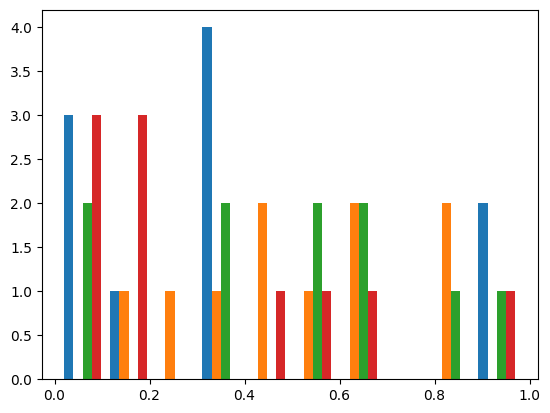

In [ ]:
# Plot the histogram of the generated array. What shape is the distribution? How does the shape change with large numbers of sampled points?
plt.hist(randarray)

In [ ]:
# In this cell, write code to generate an array named 'randarraylarge' with 10,000 random points.


In [ ]:
# Show the histogram of your new array.


In [ ]:
# Use this cell to generate 1000 random numbers between 0 and 5.
# Remember that the np.random.rand() command generates numbers between 0 and 1.


In [ ]:
# Use this cell to generate 1000 random numbers between 2 and 7.


In [ ]:
# Use this cell to generate 1000 random numbers between -5 and 5.


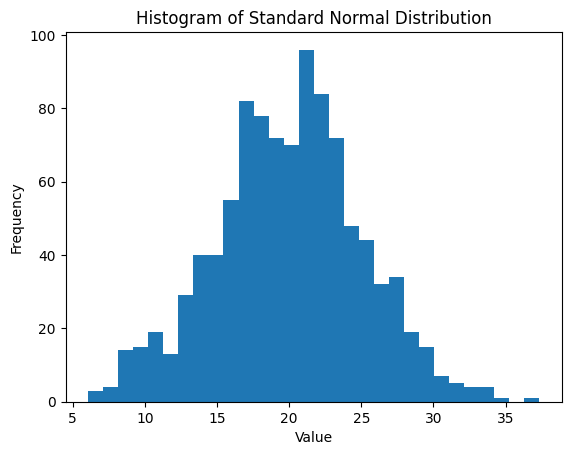

In [ ]:
# You can directly determine what kind of distribution you want to sample beyond the uniform distribution.
# The following command sets a variable that represents the standard normal distribution with a mean of 20 and standard deviation of 5.

data_normal = np.random.normal(loc=20, scale=5, size=1000)
plt.hist(data_normal, bins=30)
plt.title('Histogram of Standard Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


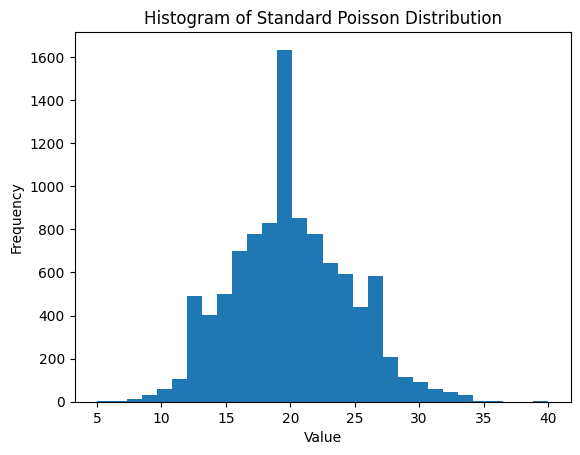

In [ ]:
# This command will generate a variable that reflects the Poisson distribution with λ=20 for 10,000 data points.
data_poisson = np.random.poisson(lam=20, size=10**4)
plt.hist(data_poisson, bins=30)
plt.title('Histogram of Standard Poisson Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Play around with the Poisson distribution. Use a smaller size of random points and a larger size of random data points. What do you observe in terms of the distribution?


The Poisson and normal distributions are not the same, though they can resemble each other under certain conditions. The Poisson distribution is discrete, modeling counts of events, while the normal distribution is continuous, modeling continuous data. They differ in shape, symmetry, and parameters.
Key differences between the two include:


*  **Data Type**: The Poisson distribution models discrete, non-negative integers (e.g., counts). The normal distribution models continuous data (e.g., height, weight).
*   **Symmetry/Shape**: Poisson is often skewed, particularly for small means, while the normal distribution is always symmetric and bell-shaped.
*   **Parameters**: Poisson is defined by one parameter (mean λ), and its variance equals its mean (σ<sup>2</sup>=λ). Normal is defined by two independent parameters (mean λ and variance σ<sup>2</sup>).
*   **Relationship**: As the mean λ of a Poisson distribution becomes large (e.g., > 10), it looks like a normal distribution and can be approximated by it.

Binomial distributions result from counting the number of occurrences given independent samples with probability of occurence *p*. For instance, if the probability of a mutation is *p*=10<sup>-8</sup>. Regardless of whether the mutations are dependent or independent of selection, you would need a large number of cells to observe a mutant.
The binomial distribution denotes the probability that *k* events occur out of a total of *n* trials given the per trial probability *p*. The function of the distribution is:

$P(k; n, p) = \binom{n}{k} p^k (1-p)^{n-k}$

where $\binom{n}{k}$ is the [binomial coefficient](https://en.wikipedia.org/wiki/Binomial_coefficient), usually pronounced "n choose k", and which denotes the number of unique ways of choosing k of n elements.

If the occurrences are rare and the number of samples is large, then the binomial distribution resembles the Poisson distribution.

To see the difference visually, we can plot the **Cumulative Distribution Function (CDF)** of the binomial and the Poisson distributions.

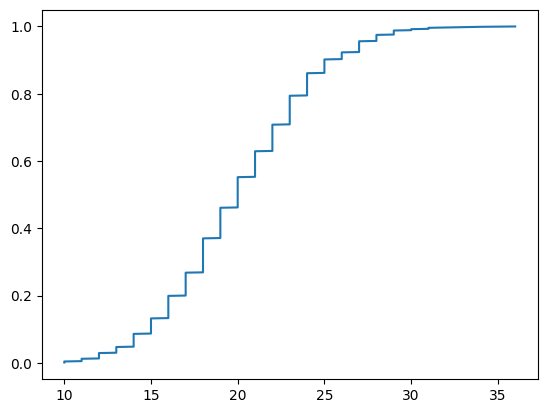

In [ ]:
# The following code obtains and plots the CDF for binomial random numbers given 100 trials with probability p=0.2:
n=100
my_lambda=20
p=my_lambda/n
nums=10**3
data_binomial = np.random.binomial(n=n, p=p, size=nums)
sortbinomial = np.sort(data_binomial)
cdfbinomial = np.arange(1, nums+1) / nums
plt.plot(sortbinomial, cdfbinomial)

# The binomial here will sample random binomial numbers and sorting allows for calculation of the CDF.

In [ ]:
# Use this cell to prepare and plot the CDF of the Poisson distribution prepared above ('data_poisson').


In [ ]:
# Compare the binomial and Poisson CDFs by plotting them in the same graph.
# Use n=40, 100, and 1000, assuming there is an expected number of 20 events such that the probability per event decreases from 0.5 to 0.2 to 0.02.


After completing this notebook, continue with the notebook that discusses the Luria-Delbruck experiment.